In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/Colab Notebooks/alzheimer-prediction.zip" -d "/content/drive/MyDrive"

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

df = pd.read_csv("/content/drive/MyDrive/archive/train.csv")
df.head()

,filename,label
0,train_000001.jpg,MildDemented
1,train_000002.jpg,MildDemented
2,train_000003.jpg,NonDemented
3,train_000004.jpg,VeryMildDemented
4,train_000005.jpg,VeryMildDemented


In [18]:
df['label'].value_counts()

,count
label,
NonDemented,9600
MildDemented,8960
VeryMildDemented,8960
ModerateDemented,6464


In [5]:
IMG_DIR = "train_images/"
CLASSES = ["NonDemented", "VeryMildDemented",
           "MildDemented", "ModerateDemented"]

# filename에 .jpg 이미 포함되어 있으므로 그대로 사용
df["path"] = IMG_DIR + df["filename"]

print(f"전체 이미지 수: {len(df)}")
print(df[["filename", "label", "path"]].head())

전체 이미지 수: 33984
           filename             label                           path
0  train_000001.jpg      MildDemented  train_images/train_000001.jpg
1  train_000002.jpg      MildDemented  train_images/train_000002.jpg
2  train_000003.jpg       NonDemented  train_images/train_000003.jpg
3  train_000004.jpg  VeryMildDemented  train_images/train_000004.jpg
4  train_000005.jpg  VeryMildDemented  train_images/train_000005.jpg


/tmp/ipykernel_1283/2930509095.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values,
/tmp/ipykernel_1283/2930509095.py:16: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/2930509095.py:16: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/2930509095.py:16: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/2930509095.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/2930509095.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


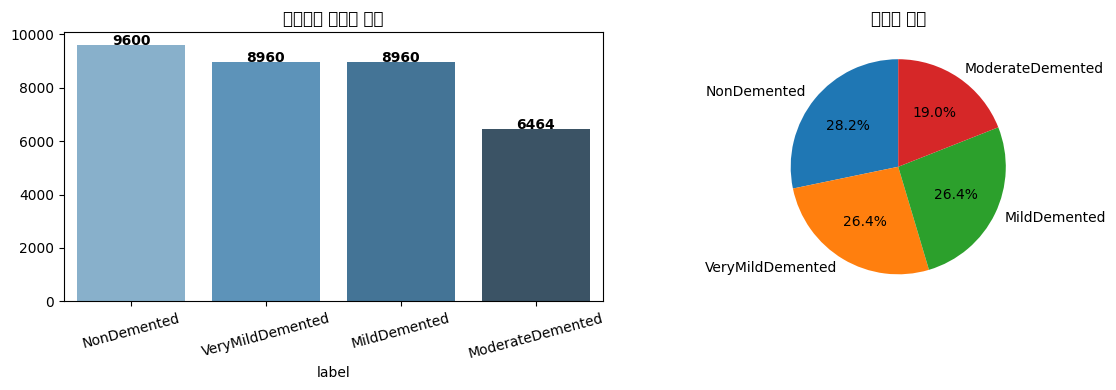

label
NonDemented         9600
VeryMildDemented    8960
MildDemented        8960
ModerateDemented    6464
Name: count, dtype: int64


In [6]:
class_counts = df["label"].value_counts().reindex(CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=class_counts.index, y=class_counts.values,
            ax=axes[0], palette="Blues_d")
axes[0].set_title("클래스별 이미지 개수")
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("클래스 비율")

plt.tight_layout()
plt.show()

print(class_counts)

Resolution types: {(180, 180), (200, 190)}
Channel distribution: Counter({3: 800})


/tmp/ipykernel_1283/2392611477.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x="label", y="pixel_mean",


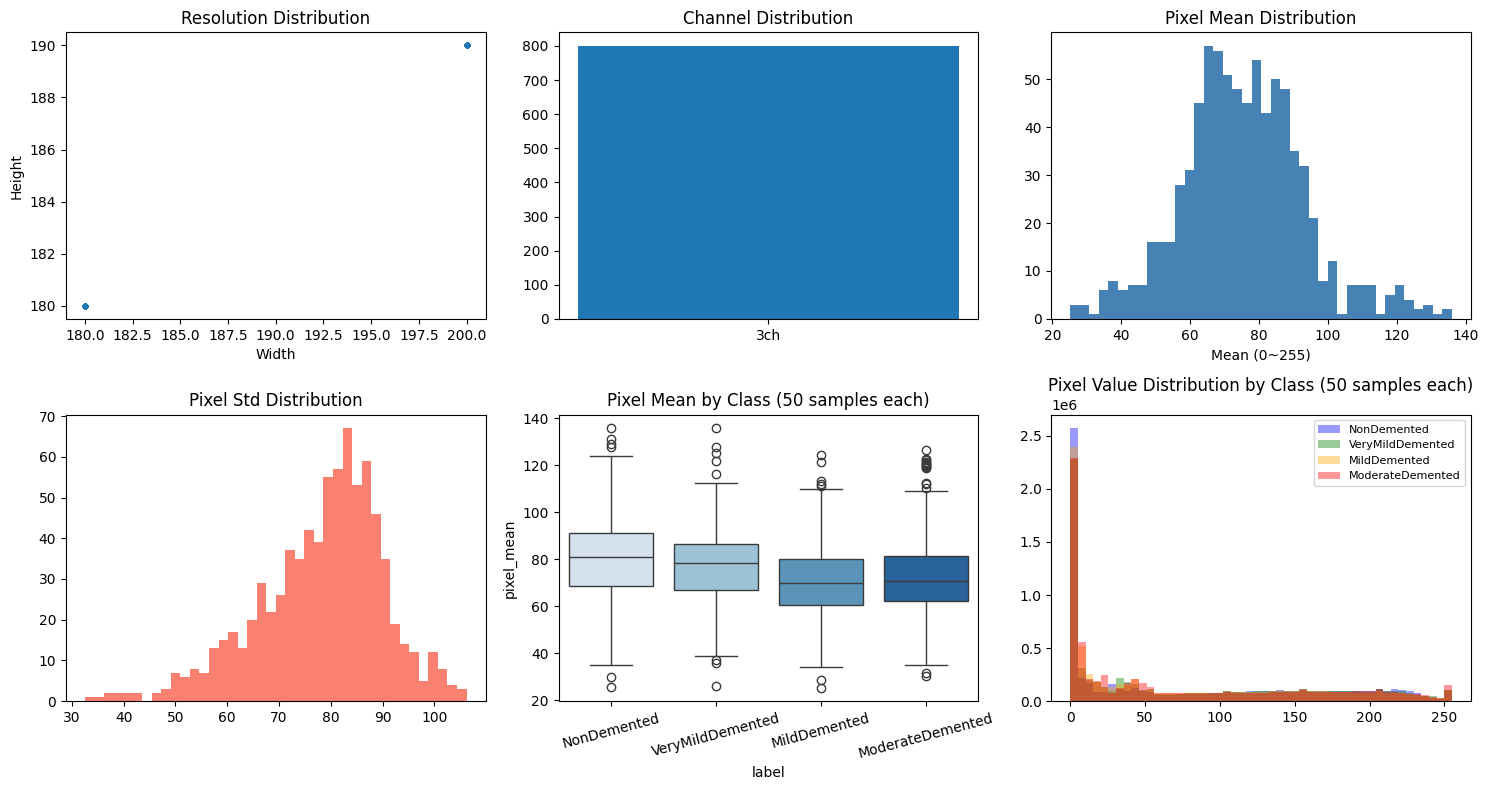

In [22]:
# 클래스별 200장씩 샘플링
sample_df = pd.concat([
    df[df["label"] == cls].sample(200, random_state=42)
    for cls in CLASSES
])

widths, heights, channels, means, stds = [], [], [], [], []

for path in sample_df["path"]:
    with Image.open("/content/drive/MyDrive/archive/" + path) as img:
        arr = np.array(img)
        widths.append(img.width)
        heights.append(img.height)
        channels.append(len(img.getbands()))
        means.append(arr.mean())
        stds.append(arr.std())

sample_df = sample_df.copy()
sample_df["width"]      = widths
sample_df["height"]     = heights
sample_df["channels"]   = channels
sample_df["pixel_mean"] = means
sample_df["pixel_std"]  = stds

print(f"Resolution types: {set(zip(widths, heights))}")
print(f"Channel distribution: {Counter(channels)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0][0].scatter(widths, heights, alpha=0.5, s=10)
axes[0][0].set_title("Resolution Distribution") # 해상도 분
axes[0][0].set_xlabel("Width"); axes[0][0].set_ylabel("Height")

ch_cnt = Counter(channels)
axes[0][1].bar([f"{k}ch" for k in ch_cnt], ch_cnt.values())
axes[0][1].set_title("Channel Distribution") # 채널 수 분

axes[0][2].hist(means, bins=40, color="steelblue")
axes[0][2].set_title("Pixel Mean Distribution") # 픽셀 평균값 분
axes[0][2].set_xlabel("Mean (0~255)")

axes[1][0].hist(stds, bins=40, color="salmon")
axes[1][0].set_title("Pixel Std Distribution") # 픽셀 표준편차 분포

sns.boxplot(data=sample_df, x="label", y="pixel_mean",
            order=CLASSES, ax=axes[1][1], palette="Blues")
axes[1][1].set_title("Pixel Mean by Class (200 samples)") # 클래스 별 평균
axes[1][1].tick_params(axis='x', rotation=15)

colors = ["blue", "green", "orange", "red"]
for cls, color in zip(CLASSES, colors):
    pixels = np.concatenate([
        np.array(Image.open("/content/drive/MyDrive/archive/" + p).convert("L")).flatten()
        for p in sample_df[sample_df["label"] == cls]["path"]
    ])
    axes[1][2].hist(pixels, bins=50, alpha=0.4, label=cls, color=color)
axes[1][2].legend(fontsize=8)
axes[1][2].set_title("Pixel Value Distribution by Class") # 클래스 별 픽셀 값 분포

plt.tight_layout()
plt.show()

/tmp/ipykernel_1283/378842528.py:11: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/378842528.py:11: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/378842528.py:11: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/378842528.py:11: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/378842528.py:11: UserWarning: Glyph 54589 (\N{HANGUL SYLLABLE PIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/378842528.py:11: UserWarning: Glyph 49472 (\N{HANGUL SYLLABLE SEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1283/378842528.py:11: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layo

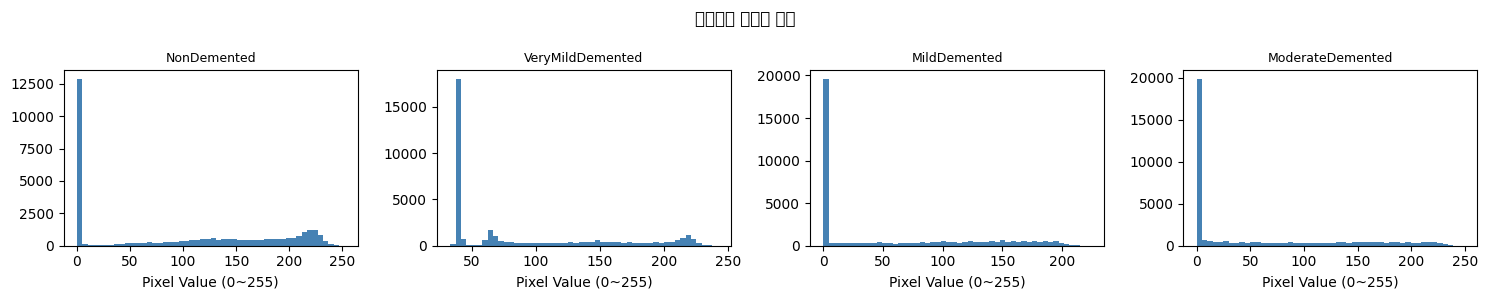

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
# 각 클래스에서 하나씩만 꺼내와서 픽셀 값 분포
for i, cls in enumerate(CLASSES):
    path = df[df["label"] == cls].iloc[0]["path"]
    arr = np.array(Image.open("/content/drive/MyDrive/archive/" + path).convert("L")).flatten()
    axes[i].hist(arr, bins=50, color="steelblue")
    axes[i].set_title(cls, fontsize=9)
    axes[i].set_xlabel("Pixel Value (0~255)")

plt.suptitle("Pixel Value Distribution by Class") # 클래스 별 픽셀 값 분포
plt.tight_layout()
plt.show()

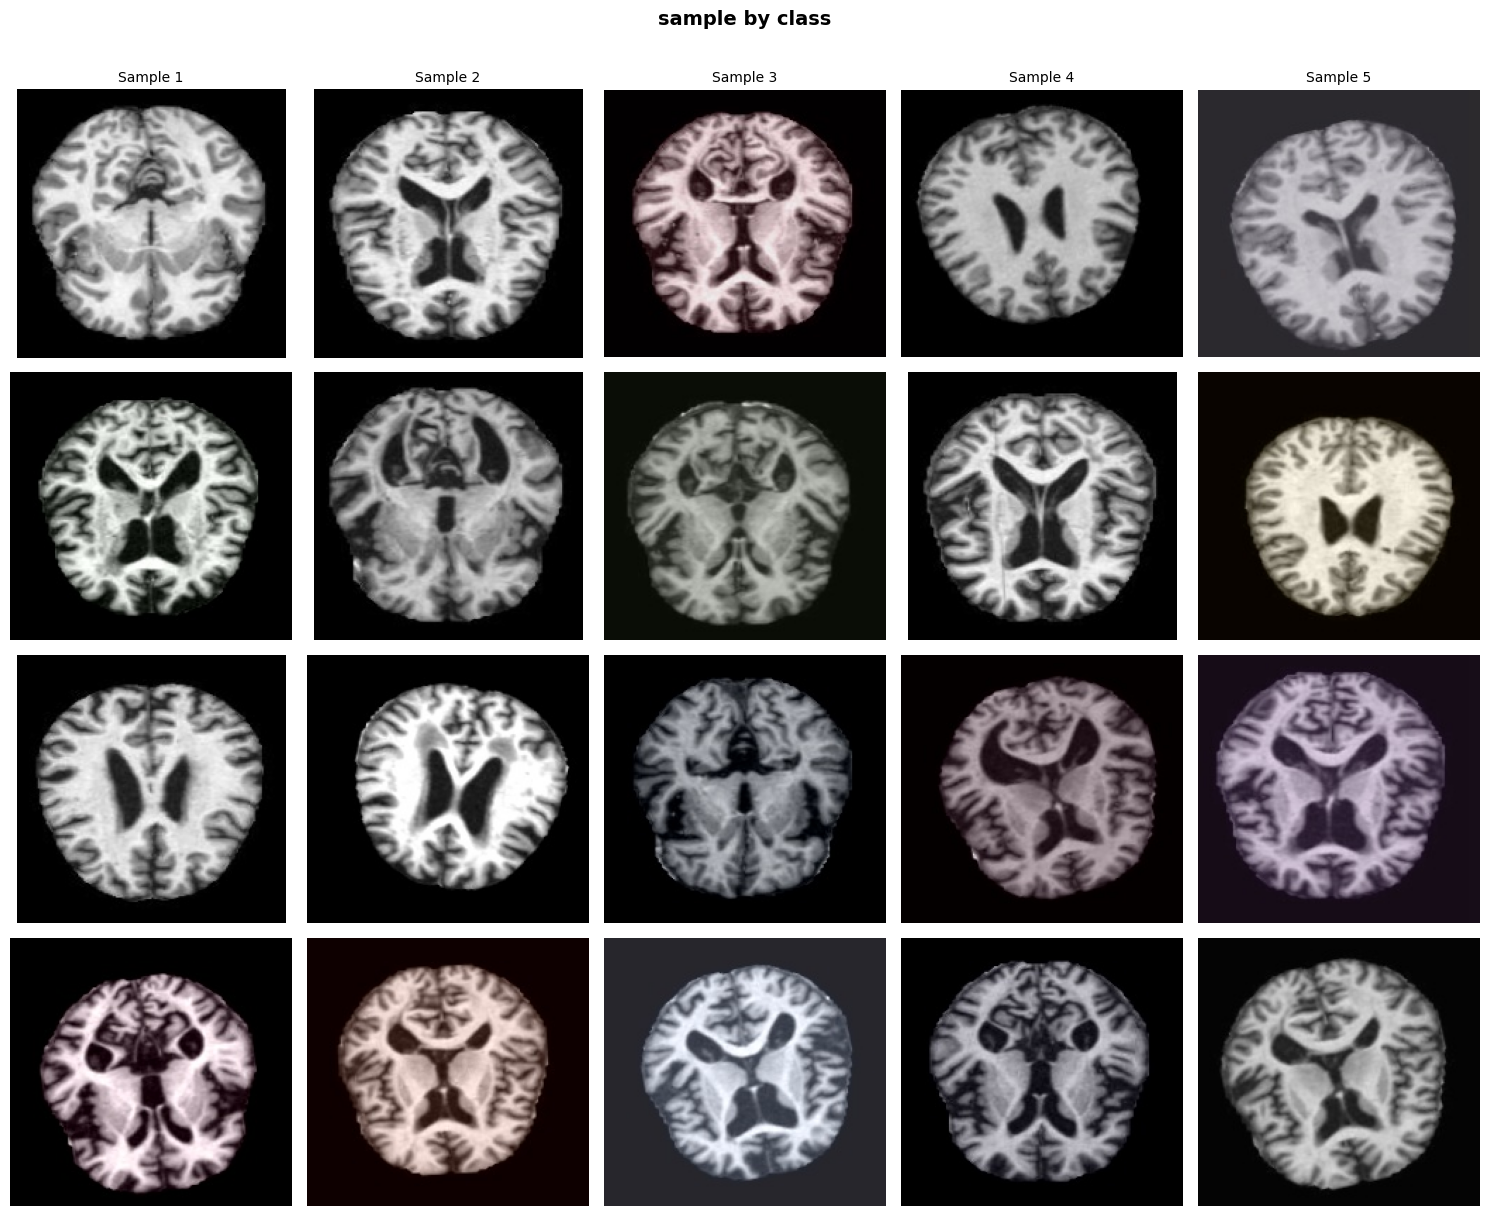

In [16]:
# 클래스별 샘플 이미지 시각화
# CLASSES = ["NonDemented", "VeryMildDemented",
#        "MildDemented", "ModerateDemented"] 맨 윗 행 부터 이 순서
n_samples = 5

fig, axes = plt.subplots(len(CLASSES), n_samples,
                         figsize=(n_samples * 3, len(CLASSES) * 3))

for i, cls in enumerate(CLASSES):
    samples = df[df["label"] == cls].sample(n_samples)["path"].values
    for j, path in enumerate(samples):
        img = Image.open("/content/drive/MyDrive/archive/" + path)
        axes[i][j].imshow(img, cmap="gray" if img.mode == "L" else None)
        axes[i][j].axis("off")
        if j == 0:
            axes[i][j].set_ylabel(cls, fontsize=11, fontweight="bold")
        if i == 0:
            axes[i][j].set_title(f"Sample {j+1}", fontsize=10)

plt.suptitle("sample by class",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()